# Introducción a los algoritmos genéticos

### 1. Instalar el módulo Deap

In [1]:
pip install deap

Note: you may need to restart the kernel to use updated packages.


### 2. Librerías necesarias

In [2]:
import random
import math
import numpy as np
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt

### 3. Definición del problema y del individuo

In [3]:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))  # Maximización = 1.0 | Minimización = -1.0
creator.create("Individual", list, fitness=creator.FitnessMax)  # El individuo es una lista con atributo fitness

### 3. Función objetivo

In [4]:
def funcion_objetivo(x):
    for i in range(len(x)):
        if x[i] > 100 or x[i] < -100:
            return -1,
    
    res = math.sqrt(x[0]**2 + x[1]**2)
    return res,#debe retornar una tupla

### 4. Convergencia del algoritmo

In [5]:
def plot_evolucion(log, num_poblacion):
    """Representa la evolución del mejor individuo en cada generación"""
    gen = np.array(log.select("gen"))
    fit_mins = np.array(log.select("min"), dtype=float)
    fit_maxs = np.array(log.select("max"), dtype=float)
    fit_ave = np.array(log.select("avg"), dtype=float)

    plt.figure(figsize=(8, 5))
    plt.plot(gen, fit_mins, "b", label="Min")
    plt.plot(gen, fit_maxs, "r", label="Max")
    plt.plot(gen, fit_ave, "--k", label="Avg")
    
    plt.fill_between(gen, fit_mins, fit_maxs, facecolor='g', alpha=0.2)
    plt.title(f"Convergencia - Población: {num_poblacion}")
    plt.xlabel("Generation")
    plt.ylabel("Fitness")
    plt.ylim([-10, 160])
    plt.legend(loc="lower center")
    plt.grid(True)
    plt.show()
    plt.savefig("Convergencia.eps", dpi = 300)

### 5. Ejecutar el algoritmo

In [8]:
def ejecutar_algoritmo(tamano_poblacion, n_generaciones=20): #20 generaciones
    """Configura y ejecuta el AG para un tamaño de población específico"""
    random.seed(42) # Para resultados reproducibles
    
    toolbox = base.Toolbox()
    
    #generación de genes y creación de individuos/población [cite: 111-129]
    toolbox.register("attr_uniform", random.uniform, -100, 100)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_uniform, 2)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual, tamano_poblacion)
    
    # operadores genéticos
    toolbox.register("evaluate", funcion_objetivo)
    toolbox.register("mate", tools.cxOnePoint)
    toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=5, indpb=0.1)
    toolbox.register("select", tools.selTournament, tournsize=3)

    # configuración de estadísticas
    pop = toolbox.population() #generación de la población inicial
    hof = tools.HallOfFame(1) # almacena al mejor individuo encontrado en todas las generaciones
    stats = tools.Statistics(lambda ind: ind.fitness.values) # generar las estadísticas de la población sobre el fitness
    stats.register("avg", np.mean) 
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)

    # ejecución del algoritmo eaSimple
    pop, logbook = algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=n_generaciones, stats=stats, halloffame=hof, verbose=False)
    return hof[0], logbook

### 6. Main

Iniciando...

gen	nevals	avg    	std     	min    	max    
0  	10    	81.3622	28.287  	31.2954	116.497
1  	2     	108.322	14.1648 	71.337 	126.071
2  	7     	116.868	9.20852 	98.8946	136.779
3  	4     	121.084	8.49836 	112.226	136.779
4  	7     	125.454	8.40708 	116.497	136.779
5  	4     	135.519	3.19937 	126.071	136.779
6  	5     	136.779	0       	136.779	136.779
7  	5     	136.779	0       	136.779	136.779
8  	10    	136.779	0       	136.779	136.779
9  	4     	136.358	1.26178 	132.573	136.779
10 	6     	136.779	0       	136.779	136.779
11 	6     	136.779	0       	136.779	136.779
12 	7     	136.779	0       	136.779	136.779
13 	7     	136.779	0       	136.779	136.779
14 	8     	122.639	41.2271 	-1     	136.779
15 	6     	136.779	0       	136.779	136.779
16 	5     	136.779	0       	136.779	136.779
17 	6     	136.779	0       	136.779	136.779
18 	6     	136.779	0       	136.779	136.779
19 	6     	136.452	0.980645	133.51 	136.779
20 	4     	136.779	0       	136.779	136.779


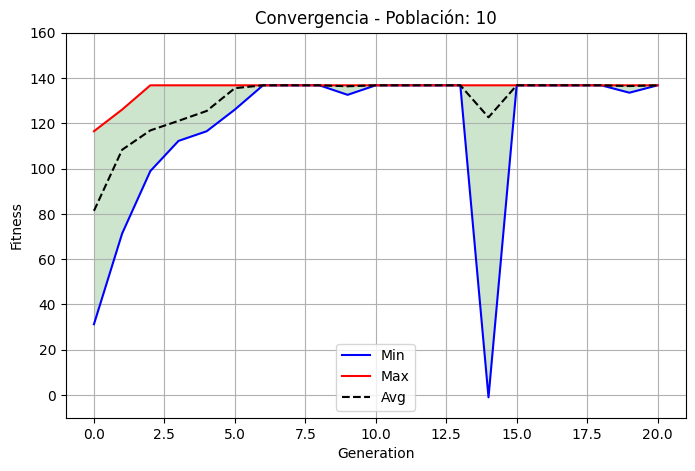

gen	nevals	avg    	std        	min    	max    
0  	30    	77.9162	24.544     	26.4289	116.497
1  	15    	98.1576	15.6516    	58.7221	123.194
2  	18    	108.641	17.0172    	47.071 	131.857
3  	24    	122.041	7.64215    	99.9797	134.549
4  	19    	128.584	3.92487    	122.005	134.549
5  	11    	132.005	2.13284    	125.135	134.549
6  	22    	133.419	1.60997    	131.169	136.779
7  	20    	130.449	24.4622    	-1     	136.779
8  	17    	136.143	1.12918    	133.455	137.464
9  	16    	136.686	0.662231   	134.132	137.486
10 	14    	137.114	0.611792   	136.779	139.908
11 	15    	137.235	1.30432    	131.674	139.908
12 	23    	137.979	0.981347   	137.464	140.041
13 	21    	133.762	25.0534    	-1     	140.101
14 	17    	138.776	1.53284    	133.594	140.101
15 	15    	130.265	35.0922    	-1     	140.101
16 	15    	140.042	0.0666659  	139.908	140.101
17 	15    	140.024	0.334088   	138.242	140.101
18 	18    	140.101	5.68434e-14	140.101	140.101
19 	20    	140.021	0.347706   	138.217	140.101
20 	20    	14

<Figure size 640x480 with 0 Axes>

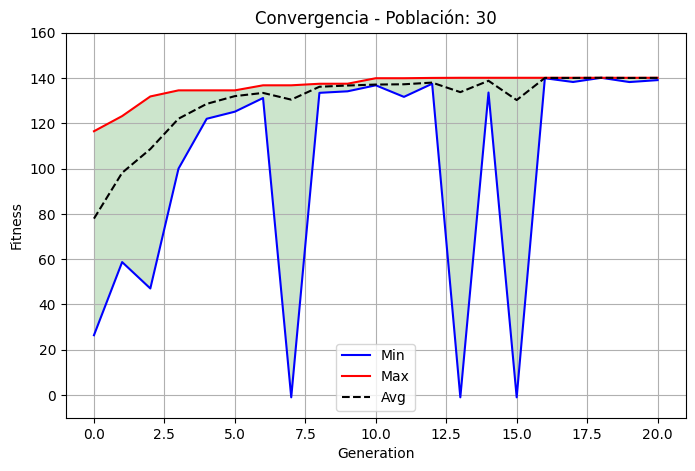

gen	nevals	avg    	std      	min    	max    
0  	50    	79.5138	24.5664  	26.4289	122.059
1  	28    	97.8301	18.6489  	48.4558	130.873
2  	28    	115.187	13.6357  	83.2838	140.132
3  	40    	124.553	19.4919  	-1     	136.574
4  	27    	133.61 	3.47646  	119.014	140.132
5  	37    	135.631	2.05285  	130.873	140.132
6  	30    	134.284	19.451   	-1     	140.132
7  	29    	135.773	19.6169  	-1     	140.132
8  	34    	137.125	19.7385  	-1     	140.132
9  	30    	140.118	0.191669 	138.887	140.677
10 	28    	140.138	0.309691 	138.232	140.677
11 	30    	140.176	0.147685 	140.132	140.677
12 	27    	140.263	0.232492 	140.132	140.677
13 	32    	137.339	19.7939  	-1     	140.677
14 	29    	140.545	0.26766  	139.41 	140.677
15 	28    	140.668	0.0591235	140.254	140.677
16 	29    	137.843	19.8347  	-1     	140.677
17 	31    	140.561	0.810355 	134.888	140.677
18 	28    	140.514	0.830834 	135.436	140.677
19 	34    	140.677	0        	140.677	140.677
20 	25    	137.843	19.8347  	-1     	140.677


<Figure size 640x480 with 0 Axes>

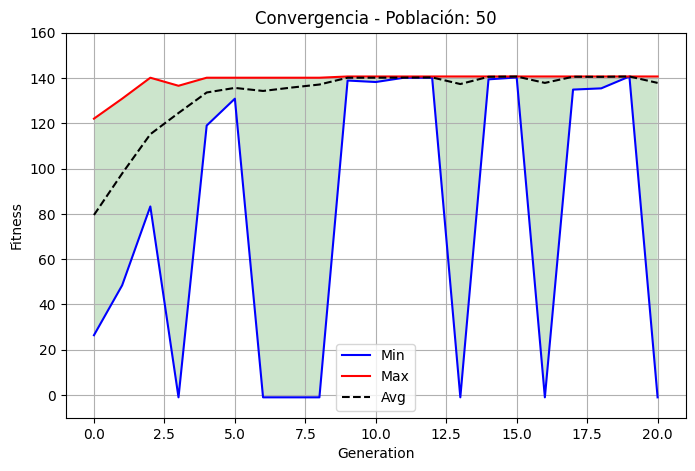


Población  | Mejor Fitness   | Mejor Solución (x, y)    
------------------------------------------------------------
10         | 136.7789        | [-94.6928, -98.7002]     
30         | 140.1008        | [-99.3464, -98.7853]     
50         | 140.6766        | [99.4752, -99.4716]      


<Figure size 640x480 with 0 Axes>

In [7]:
if __name__ == "__main__":
    tamanos = [10, 30, 50] # los 3 casos a comparar
    resultados_finales = []

    print("Iniciando...\n")

    for n in tamanos:
        mejor_ind, log = ejecutar_algoritmo(n)
        
        #guardar datos para la tabla comparativa
        resultados_finales.append({
            "Población": n,
            "Mejor Fitness": mejor_ind.fitness.values[0],
            "Mejor Individuo (x, y)": [round(c, 4) for c in mejor_ind]
        })
        #imprimir tabla
        print(log)
        
        #generar gráfica para este tamaño de población
        plot_evolucion(log, n)

    # imprimir tabla comparativa 
    print("\n" + "="*60)
    print(f"{'Población':<10} | {'Mejor Fitness':<15} | {'Mejor Solución (x, y)':<25}")
    print("-" * 60)
    for res in resultados_finales:
        print(f"{res['Población']:<10} | {res['Mejor Fitness']:<15.4f} | {str(res['Mejor Individuo (x, y)']):<25}")
    print("="*60)

### 7. Análisis de resultados 

Al usar una población más grande (50 individuos) se mejora la precisión y se obtine un fitness más cercano al máximo teórico (≈141.42).  
En comparación con las poblaciones más pequeñas de 10 y 30 se observó que convergen más rápido pero quedan estancadas en soluciones subóptimas.  
Por lo que se puede concluir que mientras más individuos hay, mayor es la probabilidad de éxito, pero también aumenta el costo computacional.